In [1]:
import pandas as pd
import numpy as np

stu_path = "/Users/emilismayilzada/Downloads/STU_QQQ_SAS/CY08MSP_STU_QQQ.parquet"
sch_path = "/Users/emilismayilzada/Downloads/SCH_QQQ_SAS/CY08MSP_SCH_QQQ.parquet"


# Predicting Student Performance with PISA 2022 (Student + School Data)

In this project we predict student achievement in PISA 2022 and explain it using:

- **Student-level information** (socio-economic status, attitudes, behaviour, etc.)
- **School-level information** (resources, climate, leadership, etc.)

Using only student data would ignore important contextual factors.  
Therefore we explicitly integrate the **school questionnaire** and merge it with the student file via the common key `CNTSCHID`.


In [2]:
# Load student and school datasets
stu = pd.read_parquet(stu_path)   # student questionnaire
sch = pd.read_parquet(sch_path)   # school questionnaire

stu.shape, sch.shape


((613744, 1278), (21629, 431))

In [3]:
print("Student data:")
display(stu.head())
stu.info()

print("\nSchool data:")
display(sch.head())
sch.info()


Student data:


,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,REGION,OECD,...,PV3MPRE,PV4MPRE,PV5MPRE,PV6MPRE,PV7MPRE,PV8MPRE,PV9MPRE,PV10MPRE,SENWT,VER_DAT
0,ALB,8.0,800282.0,800001.0,08MS,000800,ALB03,0080000,800.0,0.0,...,226.250,203.029,219.817,331.017,223.752,305.671,230.156,289.436,0.55561,03MAY23:10:11:25
1,ALB,8.0,800115.0,800002.0,08MS,000800,ALB03,0080000,800.0,0.0,...,298.644,321.405,320.452,284.836,364.565,304.044,347.626,352.269,0.76431,03MAY23:10:11:25
2,ALB,8.0,800242.0,800003.0,08MS,000800,ALB01,0080000,800.0,0.0,...,383.340,376.019,285.901,289.896,338.469,316.296,324.361,343.351,1.37877,03MAY23:10:11:25
3,ALB,8.0,800245.0,800005.0,08MS,000800,ALB08,0080000,800.0,0.0,...,264.532,303.422,327.793,165.575,246.156,238.322,275.860,227.466,1.49361,03MAY23:10:11:26
4,ALB,8.0,800285.0,800006.0,08MS,000800,ALB03,0080000,800.0,0.0,...,399.300,514.739,539.850,461.793,514.465,510.462,490.537,503.793,0.65249,03MAY23:10:11:26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613744 entries, 0 to 613743
Columns: 1278 entries, CNT to VER_DAT
dtypes: float64(1260), object(18)
memory usage: 5.8+ GB

School data:


,CNT,CNTRYID,CNTSCHID,CYC,NatCen,STRATUM,SUBNATIO,REGION,OECD,ADMINMODE,...,SCSUPRT,PROBSCRI,SCPREPBP,SCPREPAP,DIGPREP,W_SCHGRNRABWT,W_FSTUWT_SCH_SUM,W_FSTUWT_SCH_N,SENWT,VER_DAT
0,ALB,8.0,800001.0,08MS,000800,ALB05,0080000,800.0,0.0,2.0,...,2.0,0.7965,-0.8314,0.8462,0.5908,1.43376,160.58080,41.0,5.76182,03MAY23:10:11:34
1,ALB,8.0,800002.0,08MS,000800,ALB07,0080000,800.0,0.0,2.0,...,1.0,-0.5687,-0.8314,0.8462,-0.3475,2.85278,133.71140,36.0,11.46442,03MAY23:10:11:34
2,ALB,8.0,800003.0,08MS,000800,ALB06,0080000,800.0,0.0,2.0,...,1.0,0.1896,-0.8314,-0.8711,0.4409,7.40007,25.61079,3.0,29.73857,03MAY23:10:11:34
3,ALB,8.0,800004.0,08MS,000800,ALB05,0080000,800.0,0.0,2.0,...,NaN,NaN,NaN,NaN,-0.7414,4.34319,192.24130,39.0,17.45392,03MAY23:10:11:34
4,ALB,8.0,800005.0,08MS,000800,ALB03,0080000,800.0,0.0,2.0,...,2.0,0.6649,-0.8314,0.8462,-0.0102,7.52060,45.69535,5.0,30.22293,03MAY23:10:11:34


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21629 entries, 0 to 21628
Columns: 431 entries, CNT to VER_DAT
dtypes: float64(423), object(8)
memory usage: 71.1+ MB


## 2. Merging Student and School Data

Both datasets contain the variable **`CNTSCHID`** (school ID).  

- Each student belongs to exactly one school → many students per school.
- Each school appears once in the school file → one row per school.

We perform a **left merge** from student to school:

$$
\texttt{df} = \texttt{stu} \quad \text{LEFT JOIN} \quad \texttt{sch} \quad \text{ON} \quad \texttt{CNTSCHID}
$$

This preserves all students and attaches school information where available.


In [4]:
# key for merging
school_key = "CNTSCHID"

# Candidate school indices / context variables
school_feature_candidates = [
    # typical PISA school indices (names may differ slightly per release)
    "SCHLTYPE",   # public / private
    "SCHSIZE",    # school size
    "STRATIO",    # student-teacher ratio
    "SCMATEDU",   # material resources
    "SCHCLIM",    # school climate
    "TCSHORT",    # teacher shortage
    "STAFFSHORT",
    "LEADINST",   # instructional leadership
    "SCHAUTON",   # school autonomy
    "SCREADRES",  # reading resources
    "ICTSCH", "ICTAVSCH", "ICTQUAL",  # ICT resources at school
]

# Keep only those that actually exist in your school file
school_features = [c for c in school_feature_candidates if c in sch.columns]
print(f"School features found in school file: {school_features}")

# Subset school data to the key + selected features
sch_sub = sch[[school_key] + school_features].copy()

# Merge student + school data
df = stu.merge(
    sch_sub,
    on=school_key,
    how="left",
    validate="many_to_one"  # many students per one school
)

df.shape


School features found in school file: ['SCHLTYPE', 'SCHSIZE', 'STRATIO', 'STAFFSHORT']


(613744, 1282)

## 3. Feature Selection and Justification

The merged dataset `df` now has:
- all **student-level variables** (1,200+ columns),
- a set of **school-level indices** for each student.

To avoid using all 1,000+ variables, we select features based on:

1. **Theoretical relevance** according to the PISA framework  
   (demographics, socio-economic status, behaviour, attitudes, school climate, resources).
2. **Availability** in the actual files (we only use columns that exist).
3. **Interpretability**: we prefer PISA derived indices (composite scales) over individual items.

We group variables into:

- **Student Demographics & Background**
- **SES & Home Resources**
- **Behaviour & Attendance**
- **School Climate & Relationships**
- **Learning Attitudes & Self-Beliefs**
- **ICT Access & Use**
- **School-Level Context (from school file)**


In [5]:
# ---- STUDENT-LEVEL FEATURE GROUPS ----

feature_groups_student = {
    "demographics": [
        "ST004D01T",   # gender
        "AGE",
        "GRADE",
        "IMMIG",
        "LANGN",
        "REPEAT",
    ],
    "ses_home": [
        "ESCS", "HOMEPOS", "ICTRES", "HISEI",
        "MISCED", "FISCED", "HISCED", "PAREDINT",
    ],
    "behavior_attendance": [
        "SKIPPING", "TARDYSD", "MISSSC",
        "WORKPAY", "WORKHOME",
    ],
    "school_climate_student_view": [
        "DISCLIM", "TEACHSUP", "RELATST", "SCHRISK",
        "BELONG", "BULLIED", "FEELSAFE", "CURSUPP",
    ],
    "attitudes_beliefs": [
        "MATHMOT", "MATHEFF", "ANXMAT", "MATHPERS",
        "PERSEVAGR", "CURIOAGR",
    ],
    "ict_student": [
        "ICTHOME", "ICTAVHOM",
        "ICTSCH", "ICTAVSCH", "ICTQUAL",
        "ICTENQ", "ICTFEED",
    ],
}

# ---- SCHOOL-LEVEL FEATURES (already determined above) ----
feature_groups_school = {
    "school_context": school_features    # from the merge step
}

# Flatten everything and keep only existing columns in df
requested_features = []
for grp in feature_groups_student.values():
    requested_features.extend(grp)
for grp in feature_groups_school.values():
    requested_features.extend(grp)

requested_features = list(dict.fromkeys(requested_features))  # remove duplicates

selected_features = [c for c in requested_features if c in df.columns]
missing_features = [c for c in requested_features if c not in df.columns]

print(f"✅ {len(selected_features)} selected features present in merged df.")
print(f"ℹ️ {len(missing_features)} requested features not found (name differences, etc.).")
print("Example missing:", missing_features[:10])


✅ 44 selected features present in merged df.
ℹ️ 0 requested features not found (name differences, etc.).
Example missing: []


In [6]:
# Feature matrix
X = df[selected_features].copy()

# Target: average of PV1MATH ... PV10MATH
math_pv_cols = [f"PV{i}MATH" for i in range(1, 11) if f"PV{i}MATH" in df.columns]
print("Math plausible value columns:", math_pv_cols)

y_math = df[math_pv_cols].mean(axis=1).rename("math_score")

X.shape, y_math.shape


Math plausible value columns: ['PV1MATH', 'PV2MATH', 'PV3MATH', 'PV4MATH', 'PV5MATH', 'PV6MATH', 'PV7MATH', 'PV8MATH', 'PV9MATH', 'PV10MATH']


((613744, 44), (613744,))

## 4. Data Cleaning and Train/Validation Split

Before building a model, we:
- remove rows with missing target (`math_score`),
- split the data into **training** and **validation** sets,
- later apply imputation and scaling inside a pipeline.

This allows us to evaluate the model on unseen data and avoid information leakage.


In [7]:
from sklearn.model_selection import train_test_split

# 1. Drop rows with missing target
mask = ~y_math.isna()
X_clean = X.loc[mask].copy()
y_clean = y_math.loc[mask].copy()

print("After dropping missing targets:", X_clean.shape, y_clean.shape)

# 2. Train/validation split (80% / 20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_valid.shape


After dropping missing targets: (613744, 44) (613744,)


((490995, 44), (122749, 44))

## 5. Modelling: Ridge Regression with Preprocessing

We build a baseline regression model to predict `math_score`.

Steps:
1. **Impute** missing feature values with the median (features are mostly numeric indices).
2. **Standardize** features (mean 0, variance 1) so coefficients are comparable.
3. Fit a **Ridge regression** model, which is a linear model with L2 regularization.

We evaluate performance on the validation set using:
- R² (explained variance),
- MAE (mean absolute error),
- RMSE (root mean squared error).


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# All our selected features are numeric
num_features = X_train.columns.tolist()

# Preprocessing: impute + scale
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features),
    ],
    remainder="drop"
)

# Ridge regression model
model = Ridge(alpha=1.0, random_state=42)

# Full pipeline
pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", model)
])

# Fit model
pipe.fit(X_train, y_train)

# Predict on validation set
y_pred = pipe.predict(X_valid)

r2  = pipe.score(X_valid, y_valid)
mae = mean_absolute_error(y_valid, y_pred)

mse = mean_squared_error(y_valid, y_pred)  # no 'squared' argument
rmse = np.sqrt(mse)

print(f"R²:   {r2:.3f}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


R²:   0.468
MAE:  57.11
RMSE: 71.82


## 6. Modelling: XGBoost Gradient Boosting

As a stronger non-linear model, we train an **XGBoost regressor** to predict `math_score` using the same feature set.

Steps:
1. **Impute** missing feature values with the median (numerical background indices and scales).
2. Use a **tree-based gradient boosting model (XGBoost)**, which:
   - can model non-linear relationships between features and achievement,
   - can automatically capture interactions between student- and school-related variables,
   - works directly on the original feature scales (no standardization needed).

We evaluate performance on the validation set using:
- **R²** (explained variance),
- **MAE** (mean absolute error),
- **RMSE** (root mean squared error).



In [9]:
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preprocess_xgb = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
    ],
    remainder="drop"
)

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

xgb_pipe = Pipeline(steps=[
    ("prep", preprocess_xgb),
    ("model", xgb_model),
])

xgb_pipe.fit(X_train, y_train)

y_pred_xgb = xgb_pipe.predict(X_valid)

r2_xgb  = xgb_pipe.score(X_valid, y_valid)
mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)
mse_xgb = mean_squared_error(y_valid, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("XGBoost performance:")
print(f"R²:   {r2_xgb:.3f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")


XGBoost performance:
R²:   0.658
MAE:  45.36
RMSE: 57.60


## 7. Model Comparison: Ridge vs XGBoost

We compare the baseline **Ridge regression** model with the non-linear **XGBoost** model on the same validation set.

| Model    | R²    | MAE   | RMSE  |
|----------|-------|-------|-------|
| Ridge    | 0.468 | 57.11 | 71.82 |
| XGBoost  | 0.658 | 45.36 | 57.60 |

Interpretation:

- **Explained variance (R²):**  
  XGBoost increases R² from **0.468** to **0.658**, which means it explains substantially more of the variation in students’ mathematics scores (around 40% more explained variance compared to the linear baseline).

- **Prediction error (MAE / RMSE):**  
  XGBoost reduces MAE from **57.11** to **45.36** and RMSE from **71.82** to **57.60**, corresponding to roughly a **20% reduction** in prediction error.

Overall, **XGBoost clearly outperforms Ridge regression** on this task.  
In the rest of the analysis, we therefore use **XGBoost as the main predictive model**, while keeping Ridge regression as a simpler, interpretable baseline for comparison.


In [10]:
import sys
!{sys.executable} -m pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 5.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 9.9 MB/s  0:00:0010.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 2.9 MB/s  0:00:12 eta 0:00:010:01:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]━━━━━━ 5/6 [shap] [numba]


In [11]:
import shap
import numpy as np
import pandas as pd

shap.initjs()  # for nice JS plots in notebook

# 1) Take a smaller sample for SHAP (faster, avoids RAM issues)
X_valid_sample = X_valid.sample(2000, random_state=42)  # you can change size
X_valid_prep = xgb_pipe.named_steps["prep"].transform(X_valid_sample)

# Make a DataFrame so SHAP knows feature names
X_valid_prep_df = pd.DataFrame(X_valid_prep, columns=num_features)

# 2) Get the trained XGBoost model from the pipeline
xgb_model = xgb_pipe.named_steps["model"]

# 3) Build the SHAP explainer for the tree model
explainer = shap.TreeExplainer(xgb_model)

# 4) Compute SHAP values for the sample
shap_values = explainer(X_valid_prep_df)


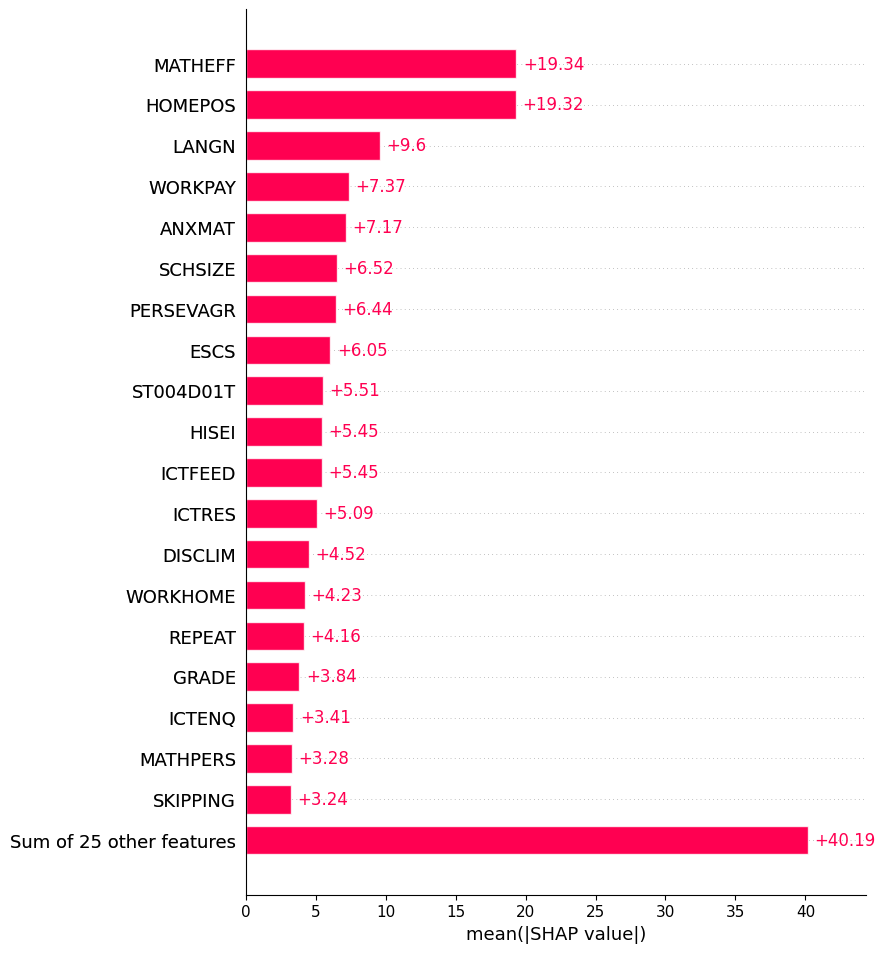

In [12]:
# Global importance: bar plot (mean |SHAP| per feature)
shap.plots.bar(shap_values, max_display=20)


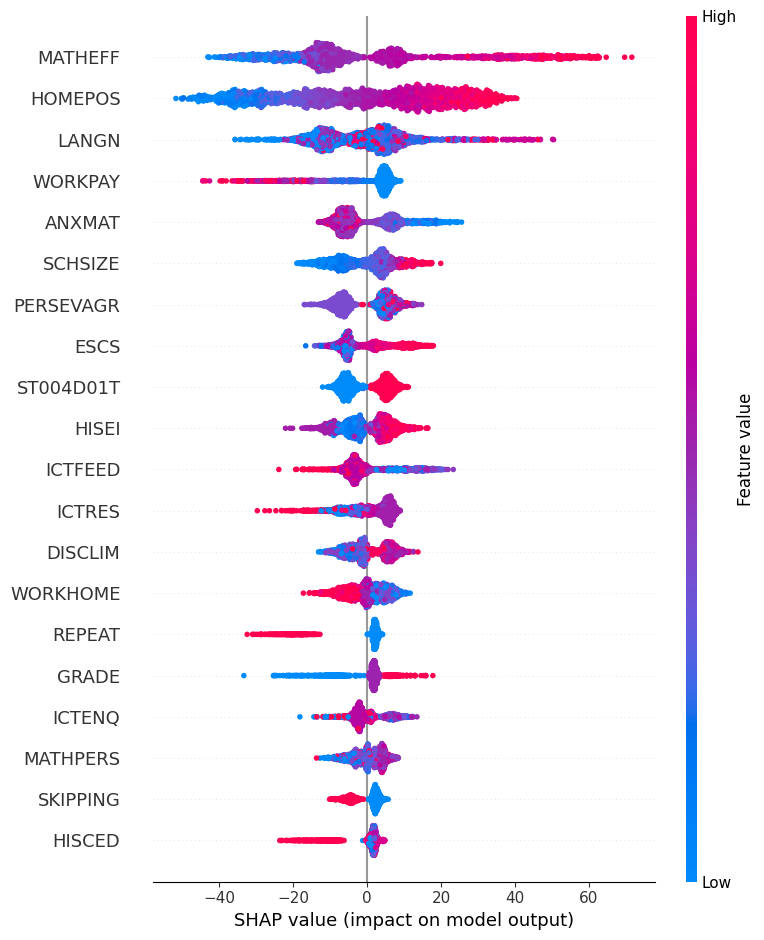

In [13]:
# Beeswarm summary plot (shows direction & distribution)
shap.summary_plot(shap_values.values, X_valid_prep_df, feature_names=num_features, max_display=20)


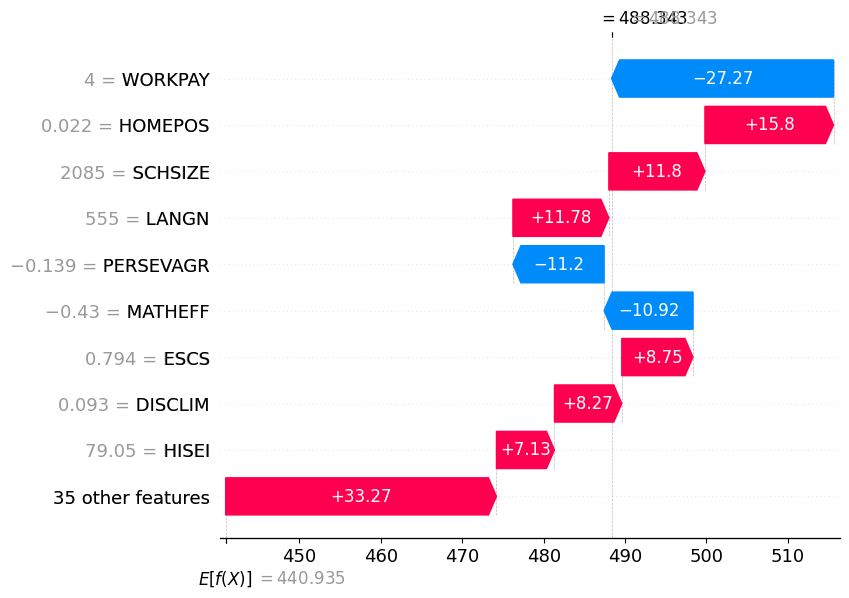

In [14]:
# Pick one student
i = 0  # change to inspect different students

student_features = X_valid_prep_df.iloc[i]
student_shap = shap_values[i]

# Waterfall plot (nice local explanation)
shap.plots.waterfall(student_shap)


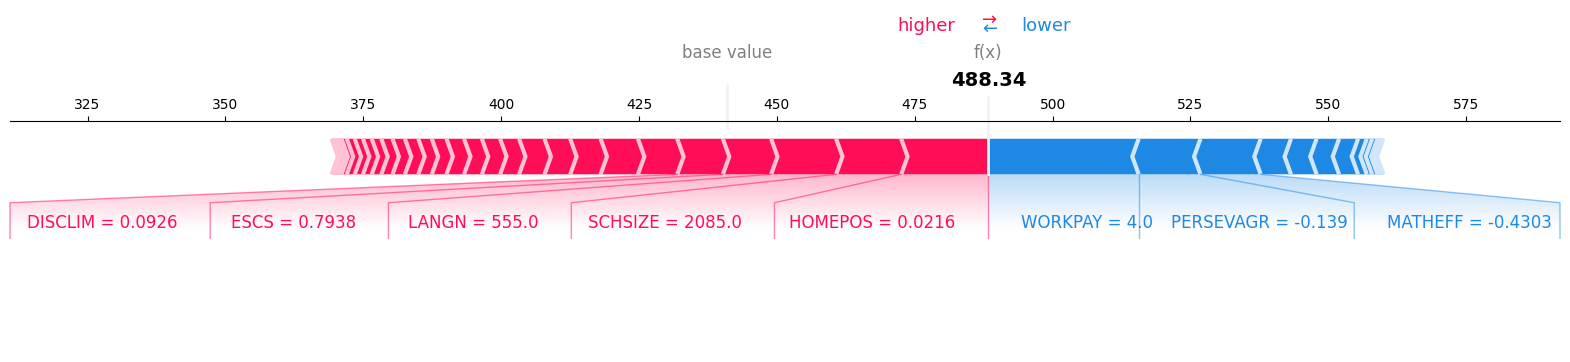

In [15]:
shap.force_plot(
    explainer.expected_value,
    student_shap.values,
    student_features,
    matplotlib=True
)
